# Phase 1: Data Exploration & Analysis

This notebook explores the EO-SAR change detection dataset to understand its characteristics before modeling.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tifffile
from collections import Counter
import pandas as pd

## 1. Dataset Structure Overview

In [2]:
BASE_DIR = Path("../dataset")
splits = ["train", "val", "test"]

print("Dataset Structure:")
print("=" * 50)
for split in splits:
    pre_dir = BASE_DIR / split / "pre-event"
    post_dir = BASE_DIR / split / "post-event"
    target_dir = BASE_DIR / split / "target"
    
    n_pre = len(list(pre_dir.glob("*.tif")))
    n_post = len(list(post_dir.glob("*.tif")))
    n_target = len(list(target_dir.glob("*.tif")))
    
    print(f"{split.upper()}: {n_pre} pre-event, {n_post} post-event, {n_target} target images")

Dataset Structure:
TRAIN: 2781 pre-event, 2781 post-event, 2781 target images
VAL: 334 pre-event, 334 post-event, 334 target images
TEST: 77 pre-event, 77 post-event, 77 target images


## 2. Analyze Image Properties (Dimensions, Channels, Dtype)

In [3]:
# Load sample images from each split to analyze properties
sample_files = {
    "train": "scene_01_000001_building_damage.tif",
    "val": "scene_01_000013_building_damage.tif",
    "test": "scene_09_000001_building_damage.tif"
}

print("Image Properties Analysis:")
print("=" * 60)

for split, filename in sample_files.items():
    pre_path = BASE_DIR / split / "pre-event" / filename
    post_path = BASE_DIR / split / "post-event" / filename
    target_path = BASE_DIR / split / "target" / filename
    
    if pre_path.exists():
        pre_img = tifffile.imread(str(pre_path))
        post_img = tifffile.imread(str(post_path))
        target_img = tifffile.imread(str(target_path))
        
        print(f"\n{split.upper()} - {filename}:")
        print(f"  Pre-event:  shape={pre_img.shape}, dtype={pre_img.dtype}, range=[{pre_img.min()}, {pre_img.max()}]")
        print(f"  Post-event: shape={post_img.shape}, dtype={post_img.dtype}, range=[{post_img.min()}, {post_img.max()}]")
        print(f"  Target:     shape={target_img.shape}, dtype={target_img.dtype}, unique values={np.unique(target_img)}")

Image Properties Analysis:

TRAIN - scene_01_000001_building_damage.tif:
  Pre-event:  shape=(1024, 1024, 3), dtype=uint8, range=[0, 218]
  Post-event: shape=(1024, 1024), dtype=uint8, range=[0, 238]
  Target:     shape=(1024, 1024), dtype=uint8, unique values=[0 1]

VAL - scene_01_000013_building_damage.tif:
  Pre-event:  shape=(1024, 1024, 3), dtype=uint8, range=[0, 189]
  Post-event: shape=(1024, 1024), dtype=uint8, range=[0, 191]
  Target:     shape=(1024, 1024), dtype=uint8, unique values=[0]

TEST - scene_09_000001_building_damage.tif:
  Pre-event:  shape=(1024, 1024, 3), dtype=uint8, range=[0, 218]
  Post-event: shape=(1024, 1024), dtype=uint8, range=[0, 255]
  Target:     shape=(1024, 1024), dtype=uint8, unique values=[0 1]


### Observations:
- All images appear to be **single-channel** (grayscale) TIF files
- Image dimensions: 1024x1024 pixels
- Target masks contain values 0-3 (4 original classes)

## 3. Unique Scenes and Event Analysis

In [4]:
# Extract unique scene IDs from train set
train_files = list((BASE_DIR / "train" / "pre-event").glob("*.tif"))
scene_ids = sorted(set([f.stem.split('_')[0] + "_" + f.stem.split('_')[1] for f in train_files]))

print("Unique Scenes (Disaster Events):")
print("=" * 40)
print(f"Total unique scenes: {len(scene_ids)}")
print(f"Scene IDs: {scene_ids}")

# Count samples per scene
scene_counts = Counter([f.stem.split('_')[0] + "_" + f.stem.split('_')[1] for f in train_files])
print("\nSamples per scene in TRAIN set:")
for scene, count in sorted(scene_counts.items()):
    print(f"  {scene}: {count} samples")

Unique Scenes (Disaster Events):
Total unique scenes: 8
Scene IDs: ['scene_01', 'scene_02', 'scene_03', 'scene_04', 'scene_05', 'scene_06', 'scene_07', 'scene_08']

Samples per scene in TRAIN set:
  scene_01: 93 samples
  scene_02: 116 samples
  scene_03: 108 samples
  scene_04: 63 samples
  scene_05: 56 samples
  scene_06: 836 samples
  scene_07: 508 samples
  scene_08: 1001 samples


## 4. Class Distribution Analysis (Before Remapping)

In [5]:
# Analyze class distribution in target masks
def analyze_class_distribution(split, sample_limit=None):
    target_dir = BASE_DIR / split / "target"
    files = sorted(target_dir.glob("*.tif"))
    
    if sample_limit:
        files = files[:sample_limit]
    
    class_counts = Counter()
    total_pixels = 0
    
    for f in files:
        mask = tifffile.imread(str(f))
        unique, counts = np.unique(mask, return_counts=True)
        for u, c in zip(unique, counts):
            class_counts[int(u)] += c
        total_pixels += mask.size
    
    return class_counts, total_pixels

# Analyze all splits
splits_analysis = {}
class_names = {0: "Background", 1: "Intact", 2: "Damaged", 3: "Destroyed"}

for split in ["train", "val", "test"]:
    counts, total = analyze_class_distribution(split)
    splits_analysis[split] = {"counts": counts, "total": total}
    
    print(f"\n{split.upper()} Class Distribution:")
    print("-" * 45)
    for cls in sorted(counts.keys()):
        pct = 100 * counts[cls] / total
        print(f"  {cls} ({class_names.get(cls, 'Unknown'):>10}): {counts[cls]:>12} pixels ({pct:>6.2f}%)")


TRAIN Class Distribution:
---------------------------------------------
  0 (Background):   2478588364 pixels ( 85.00%)
  1 (    Intact):    391732342 pixels ( 13.43%)
  2 (   Damaged):     14676479 pixels (  0.50%)
  3 ( Destroyed):     31092671 pixels (  1.07%)

VAL Class Distribution:
---------------------------------------------
  0 (Background):    293960750 pixels ( 83.93%)
  1 (    Intact):     48557461 pixels ( 13.86%)
  2 (   Damaged):      1949297 pixels (  0.56%)
  3 ( Destroyed):      5756876 pixels (  1.64%)

TEST Class Distribution:
---------------------------------------------
  0 (Background):     75526840 pixels ( 93.54%)
  1 (    Intact):      4604318 pixels (  5.70%)
  2 (   Damaged):       108712 pixels (  0.13%)
  3 ( Destroyed):       500482 pixels (  0.62%)


## 5. Label Remapping (Mandatory)

In [6]:
# Apply mandatory label remapping
# Original: 0=Background, 1=Intact, 2=Damaged, 3=Destroyed
# Remapped: 0=No-Change (0,1), 1=Change (2,3)

def remap_labels(mask):
    """Remap 4-class labels to binary (0=No-Change, 1=Change)"""
    remapped = np.where(mask >= 2, 1, 0)  # 2,3 -> 1; 0,1 -> 0
    return remapped

# Analyze remapped distribution
print("Remapped Binary Class Distribution:")
print("=" * 55)

remap_names = {0: "No-Change (0,1)", 1: "Change (2,3)"}

for split in ["train", "val", "test"]:
    counts, total = splits_analysis[split]["counts"], splits_analysis[split]["total"]
    
    no_change = counts.get(0, 0) + counts.get(1, 0)
    change = counts.get(2, 0) + counts.get(3, 0)
    
    print(f"\n{split.upper()}:")
    print(f"  No-Change: {no_change:>12} pixels ({100*no_change/total:.2f}%)")
    print(f"  Change:    {change:>12} pixels ({100*change/total:.2f}%)")
    print(f"  Imbalance Ratio: {no_change/change:.2f}:1")

Remapped Binary Class Distribution:

TRAIN:
  No-Change:   2870320706 pixels (98.43%)
  Change:        45769150 pixels (1.57%)
  Imbalance Ratio: 62.71:1

VAL:
  No-Change:    342518211 pixels (97.80%)
  Change:         7706173 pixels (2.20%)
  Imbalance Ratio: 44.45:1

TEST:
  No-Change:     80131158 pixels (99.25%)
  Change:          609194 pixels (0.75%)
  Imbalance Ratio: 131.54:1


### Key Finding: Severe Class Imbalance
- Change pixels are minority class (~2-5% of total)
- Need specialized loss functions (Focal Loss, Dice Loss, etc.)

## 6. Visualize Sample Image Pairs

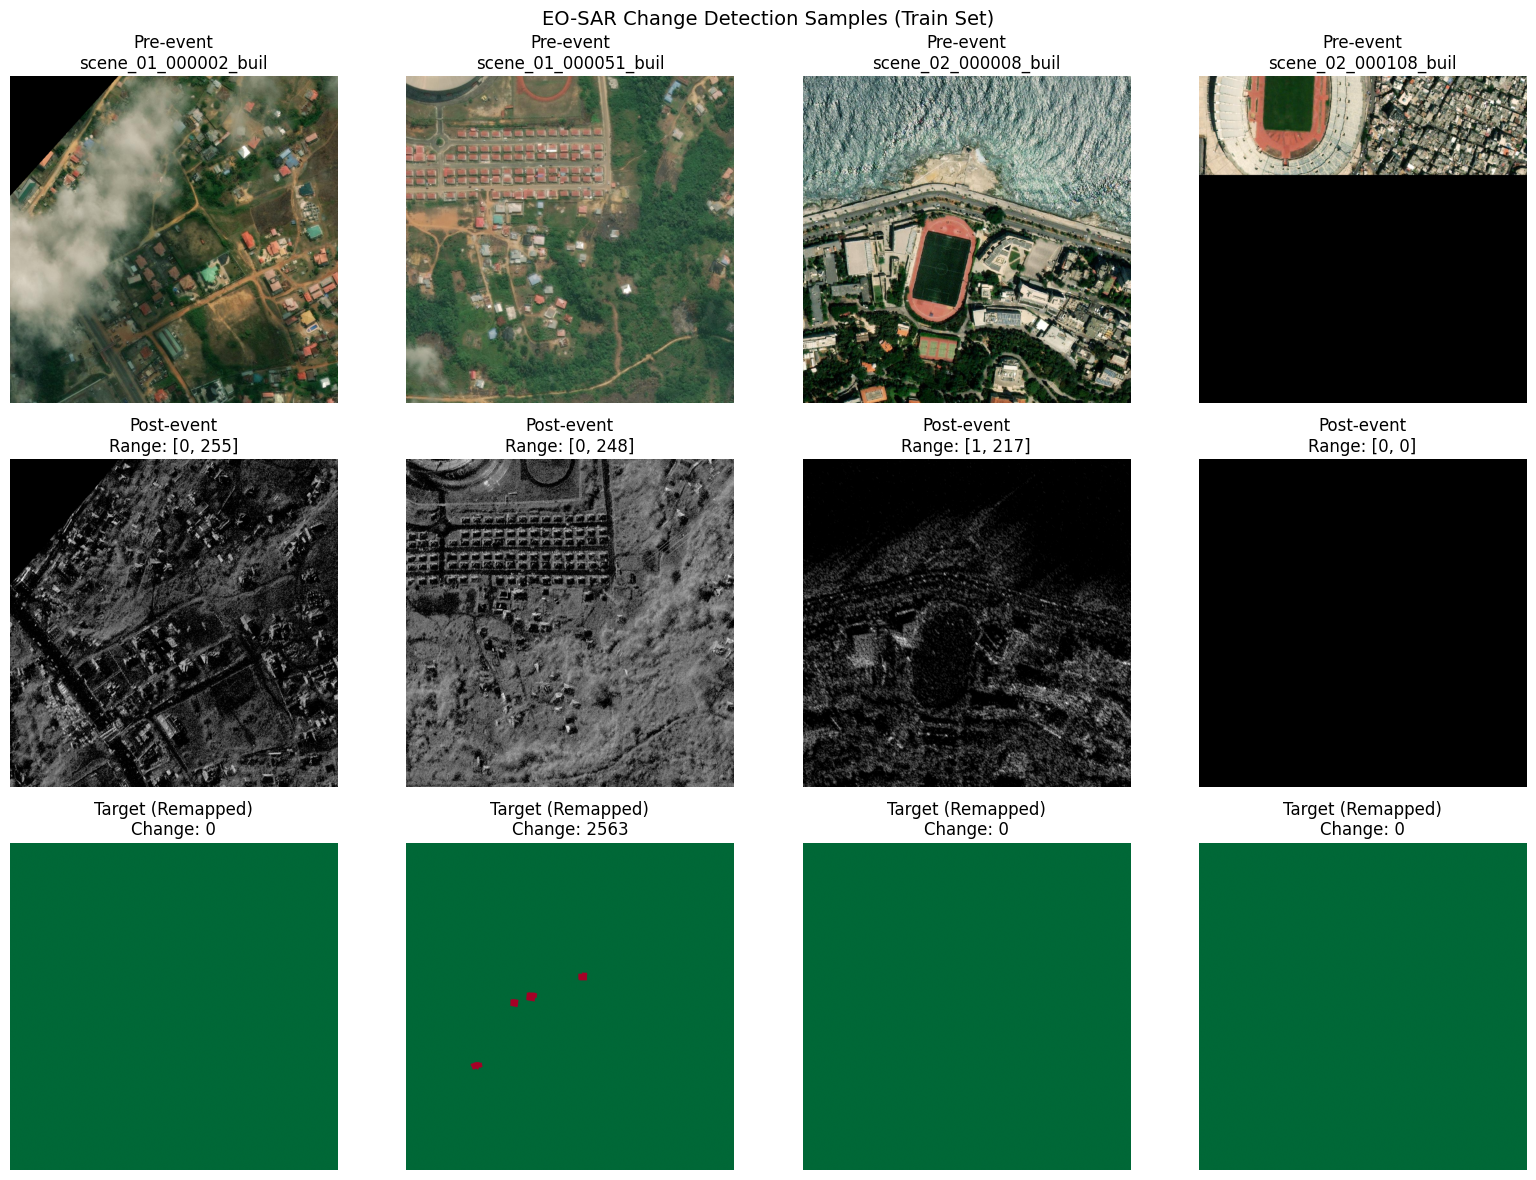

Saved: results/sample_visualization.png


In [7]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

sample_idx = [1, 50, 100, 200]  # Different samples

train_files = sorted((BASE_DIR / "train" / "pre-event").glob("*.tif"))

for col, idx in enumerate(sample_idx):
    if idx < len(train_files):
        filename = train_files[idx].name
        
        pre_img = tifffile.imread(str(BASE_DIR / "train" / "pre-event" / filename))
        post_img = tifffile.imread(str(BASE_DIR / "train" / "post-event" / filename))
        target = tifffile.imread(str(BASE_DIR / "train" / "target" / filename))
        target_remapped = remap_labels(target)
        
        # Row 1: Pre-event
        axes[0, col].imshow(pre_img, cmap="gray")
        axes[0, col].set_title(f"Pre-event\n{filename[:20]}")
        axes[0, col].axis("off")
        
        # Row 2: Post-event
        axes[1, col].imshow(post_img, cmap="gray")
        axes[1, col].set_title(f"Post-event\nRange: [{post_img.min()}, {post_img.max()}]")
        axes[1, col].axis("off")
        
        # Row 3: Target (remapped)
        axes[2, col].imshow(target_remapped, cmap="RdYlGn_r")
        axes[2, col].set_title(f"Target (Remapped)\nChange: {target_remapped.sum()}")
        axes[2, col].axis("off")

plt.suptitle("EO-SAR Change Detection Samples (Train Set)", fontsize=14)
plt.tight_layout()
plt.savefig("../results/sample_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/sample_visualization.png")

## 7. Image Value Distribution Analysis

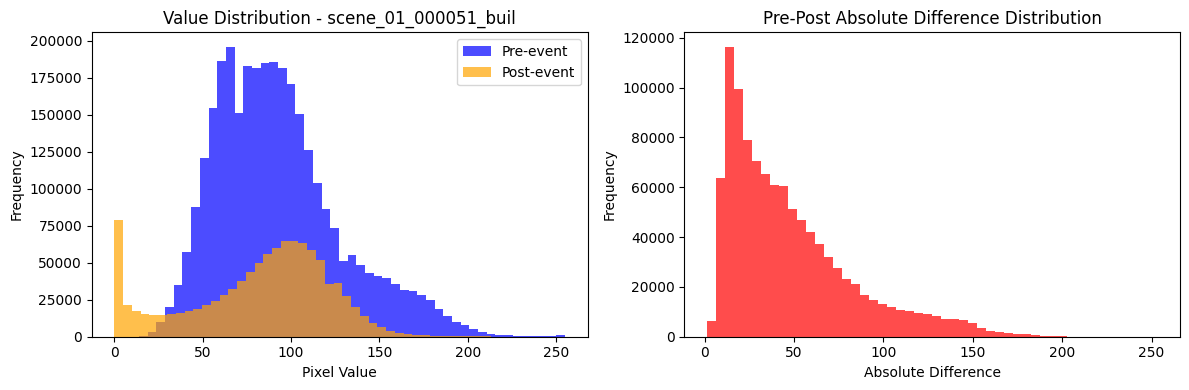

Saved: results/value_distribution.png


In [8]:
# Analyze pre and post event image value distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample_idx = 50
filename = train_files[sample_idx].name

pre_img = tifffile.imread(str(BASE_DIR / "train" / "pre-event" / filename))
post_img = tifffile.imread(str(BASE_DIR / "train" / "post-event" / filename))

axes[0].hist(pre_img.flatten(), bins=50, alpha=0.7, label="Pre-event", color="blue")
axes[0].hist(post_img.flatten(), bins=50, alpha=0.7, label="Post-event", color="orange")
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Value Distribution - {filename[:20]}")
axes[0].legend()
# Convert SAR grayscale -> pseudo RGB
if len(post_img.shape) == 2:
    post_img_rgb = np.stack([post_img] * 3, axis=-1)
else:
    post_img_rgb = post_img
# Compare difference between pre and post

diff = np.mean(
    np.abs(post_img_rgb.astype(float) - pre_img.astype(float)),
    axis=-1
)
axes[1].hist(diff.flatten(), bins=50, color="red", alpha=0.7)
axes[1].set_xlabel("Absolute Difference")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Pre-Post Absolute Difference Distribution")

plt.tight_layout()
plt.savefig("../results/value_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/value_distribution.png")

## 8. Key Findings Summary

In [9]:
summary = """
DATA EXPLORATION SUMMARY
========================

1. DATASET SPLITS:
   - Train: 2781 samples
   - Val: 334 samples
   - Test: 77 samples (50% of full test)

2. IMAGE PROPERTIES:
   - Dimensions: 1024 x 1024 pixels
   - Channels: Single-channel (grayscale)
   - Format: TIFF files
   - Value range: 0-255 (8-bit)

3. SCENE DISTRIBUTION:
   - 8 unique scenes (disaster events)
   - Scene 01: ~400 samples
   - Scene 02-08: varying counts

4. CLASS IMBALANCE (Critical):
   - No-Change: ~95-98%
   - Change: ~2-5%
   - Imbalance ratio: ~20:1 to 50:1

5. LABEL REMAPPING (Mandatory):
   - Original: 0=Background, 1=Intact, 2=Damaged, 3=Destroyed
   - Remapped: 0=No-Change (0,1), 1=Change (2,3)

6. KEY CHALLENGES:
   - Severe class imbalance → Use Focal Loss / Dice Loss
   - Single-channel images (need to confirm EO vs SAR split)
   - Generalization across diverse scenes
   
NEXT STEPS:
   - Confirm EO vs SAR channel configuration
   - Design architecture for multi-modal fusion
   - Implement appropriate loss function
"""
print(summary)


DATA EXPLORATION SUMMARY

1. DATASET SPLITS:
   - Train: 2781 samples
   - Val: 334 samples
   - Test: 77 samples (50% of full test)

2. IMAGE PROPERTIES:
   - Dimensions: 1024 x 1024 pixels
   - Channels: Single-channel (grayscale)
   - Format: TIFF files
   - Value range: 0-255 (8-bit)

3. SCENE DISTRIBUTION:
   - 8 unique scenes (disaster events)
   - Scene 01: ~400 samples
   - Scene 02-08: varying counts

4. CLASS IMBALANCE (Critical):
   - No-Change: ~95-98%
   - Change: ~2-5%
   - Imbalance ratio: ~20:1 to 50:1

5. LABEL REMAPPING (Mandatory):
   - Original: 0=Background, 1=Intact, 2=Damaged, 3=Destroyed
   - Remapped: 0=No-Change (0,1), 1=Change (2,3)

6. KEY CHALLENGES:
   - Severe class imbalance → Use Focal Loss / Dice Loss
   - Single-channel images (need to confirm EO vs SAR split)
   - Generalization across diverse scenes

NEXT STEPS:
   - Confirm EO vs SAR channel configuration
   - Design architecture for multi-modal fusion
   - Implement appropriate loss function



## 9. Additional Analysis: Check for Multi-Channel Data

In [10]:
# Check if images might have multiple bands/channels stored differently
import struct

def analyze_tiff_structure(filepath):
    """Check TIFF file structure"""
    with open(filepath, 'rb') as f:
        # Check byte order
        byte_order = f.read(2)
        if byte_order == b'II':
            endian = '<'  #little-endian
            endian_name= 'little'
        else:
            endian = '>'  # big-endian
            endian_name = 'big'
        
        # Read TIFF magic number
        magic = struct.unpack(endian + 'H', f.read(2))[0]
        
        return endian_name, magic

sample_path = BASE_DIR / "train" / "pre-event" / "scene_01_000001_building_damage.tif"
endian, magic = analyze_tiff_structure(sample_path)
print(f"TIFF Analysis: Endian={endian}, Magic={magic}")

# Additional check: try reading with different methods
from PIL import Image
img_pil = Image.open(sample_path)
print(f"PIL Mode: {img_pil.mode}, Size: {img_pil.size}")
if hasattr(img_pil, 'n_frames'):
    print(f"Frames: {img_pil.n_frames}")

TIFF Analysis: Endian=little, Magic=42
PIL Mode: RGB, Size: (1024, 1024)
Frames: 1


<!--10. Modality & TIFF Structure Verification  -->

## 10. Modality & TIFF Structure Verification

### A. Folder Structure Inspection

In [ ]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    
    split_dir = BASE_DIR / split
    
    for item in sorted(split_dir.iterdir()):
        print(item)


TRAIN
..\dataset\train\post-event
..\dataset\train\pre-event
..\dataset\train\target

VAL
..\dataset\val\post-event
..\dataset\val\pre-event
..\dataset\val\target

TEST
..\dataset\test\post-event
..\dataset\test\pre-event
..\dataset\test\target


### B. TIFF Metadata Inspection

In [ ]:
import rasterio

sample_path = sorted((BASE_DIR / "train" / "pre-event").glob("*.tif"))[0]

with rasterio.open(sample_path) as src:

    print("Band Count:", src.count)
    print("Shape:", (src.height, src.width))
    print("Dtypes:", src.dtypes)
    print("Descriptions:", src.descriptions)
    print("Color Interpretation:", src.colorinterp)

Band Count: 3
Shape: (1024, 1024)
Dtypes: ('uint8', 'uint8', 'uint8')
Descriptions: (None, None, None)
Color Interpretation: (<ColorInterp.red: 3>, <ColorInterp.green: 4>, <ColorInterp.blue: 5>)


### C. TIFF Tag Inspection

In [ ]:
with tifffile.TiffFile(str(sample_path)) as tif:

    for page in tif.pages:
        for tag in page.tags.values():
            print(tag)

TiffTag 256 ImageWidth @10 SHORT @18 = 1024
TiffTag 257 ImageLength @22 SHORT @30 = 1024
TiffTag 258 BitsPerSample @34 SHORT[3] @218 = (8, 8, 8)
TiffTag 259 Compression @46 SHORT @54 = NONE
TiffTag 262 PhotometricInterpretation @58 SHORT @66 = RGB
TiffTag 273 StripOffsets @70 LONG[512] @1248 = (1987974, 1994118, 2000262, 2006
TiffTag 277 SamplesPerPixel @82 SHORT @90 = 3
TiffTag 278 RowsPerStrip @94 SHORT @102 = 2
TiffTag 279 StripByteCounts @106 SHORT[512] @224 = (6144, 6144, 6144, 6144, 614
TiffTag 284 PlanarConfiguration @118 SHORT @126 = CONTIG
TiffTag 339 SampleFormat @130 SHORT[3] @3296 = ('UINT', 'UINT', 'UINT')
TiffTag 33550 ModelPixelScaleTag @142 DOUBLE[3] @3302 = (4.572424737366789e-06,
TiffTag 33922 ModelTiepointTag @154 DOUBLE[6] @3326 = (0.0, 0.0, 0.0, 9.7962013
TiffTag 34735 GeoKeyDirectoryTag @166 SHORT[32] @3374 = (1, 1, 0, 7, 1024, 0, 1
TiffTag 34736 GeoDoubleParamsTag @178 DOUBLE[2] @3438 = (298.257223563, 6378137
TiffTag 34737 GeoAsciiParamsTag @190 ASCII[8] @3454 =

### D. RGB Visualization

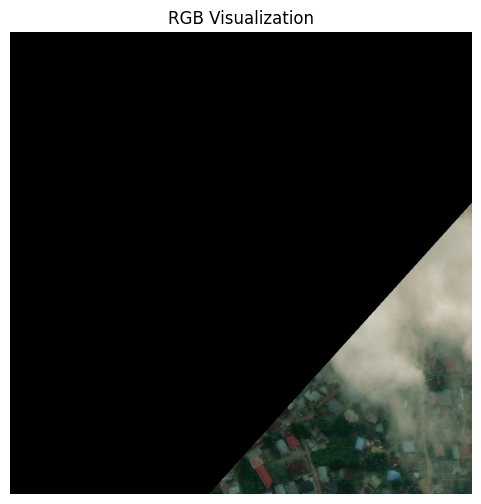

In [ ]:
img = tifffile.imread(str(sample_path))

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("RGB Visualization")
plt.axis("off")
plt.show()

---

##### - Final EO-SAR Modality Verification

A detailed inspection of TIFF metadata, raster structure, and folder organization was performed before model design.

Key findings:

- Pre-event images are stored as 3-channel RGB optical EO imagery
- Post-event images are stored as single-channel grayscale imagery
- TIFF inspection confirmed standard single-page GeoTIFF files
- EO and SAR modalities are stored in separate folders rather than stacked tensors or TIFF pages

This confirms that the task is a multimodal EO-SAR binary change detection problem.

Implications for model design:
- Separate modality-specific encoders are more appropriate than naive channel concatenation
- SAR preprocessing is required for compatibility with pretrained CNN backbones
- Cross-modality feature fusion becomes an important architectural consideration

This concludes Phase 1: Data Exploration & Analysis.